## Generating idealized synthetic data cube: imaging + IFS

This notebook demonstrates the generation of synthetic spectrophotometric (imaging + IFU) data cube. To generate the data cube using ``GalaxySynthesizer``, we first need to set up filters and their transmission curves. 

### Setting up filter transmission curves
The ``filters`` input is a list containing filter names (arbitrary) in string, whereas ``filter_transmission_path`` input is a Dictionary of paths to text files containing the transmission function. Keys are filter names (as listed in ``filters``), values are file paths. Each text file has two columns: wavelength, transmission.

Alternatively, if you have [piXedfit](https://pixedfit.readthedocs.io/en/latest/) installed, you can set up these inputs easily using ``make_filter_transmission_text_pixedfit`` function. It will create a dictionary and text files containing the filter transmission curves taken from the internal piXedfit package. For this to work, you need to use filter naming in piXedfit. Below is an example script for this:

In [1]:
from galsyn.utils import make_filter_transmission_text_pixedfit

filters = ['hst_acs_f435w', 'hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f110w', 'hst_wfc3_ir_f125w', 
            'hst_wfc3_ir_f140w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f090w', 'jwst_nircam_f115w', 
            'jwst_nircam_f140m', 'jwst_nircam_f150w', 'jwst_nircam_f200w', 'jwst_nircam_f250m', 
            'jwst_nircam_f277w', 'jwst_nircam_f300m', 'jwst_nircam_f356w', 'jwst_nircam_f410m', 
            'jwst_nircam_f444w', 'jwst_nircam_f460m', 'jwst_nircam_f480m']

filter_transmission_path = make_filter_transmission_text_pixedfit(filters, output_dir="filters")

Directory 'filters' already exists.


### Generating synthetic spectrophotometric data cube
Now, we run the synthesis process using ``GalaxySynthesizer``. The following script demonstrates the generation of spectrophotometric data cube with line-of-sight dust-attenuation modeling method and the modified Calzetti dust law with a dynamic slope and bump strength that depends on $A_{V}$. 

In [ ]:
from galsyn import GalaxySynthesizer
from galsyn.dust import relation_AVslope
from galsyn.simutils_tng import get_snap_z

# Your personal API key from the IllustrisTNG website
api_key = "your_api_key"

# Specify simulation parameters
sim = 'TNG50-1'         # The TNG simulation run
snap_number = 39        # The snapshot index (e.g., z ~ 1.5 in IllustrisTNG)
subhalo_id = 107965     # The subhalo ID

# Retrieve the exact redshift for the given snapshot number using the TNG API
z = get_snap_z(snap_number, api_key=api_key)
print ('Redshift: %lf' % z)

# Define the output path for the standardized file, generated using the script in Example 1
sim_file = f'sim_file_tng_{int(snap_number)}_{int(subhalo_id)}.hdf5'

gs = GalaxySynthesizer(sim_file, z=z, filters=filters, filter_transmission_path=filter_transmission_path)

gs.ssp_filepath = 'ssp_fsps.hdf5'         # path to the FSPS SSP grids generated in Example 2
gs.ssp_interpolation_method = 'nearest'

gs.dim_kpc = 90                # Image side length in kpc
gs.smoothing_length = 0.15     # Smoothing length of the simulation in kpc
gs.pix_arcsec = 0.03           # Output pixel scale in arcseconds

# Desired unit for the imaging data
# IFS data would always have flux unit of erg/s/cm^2/Angstrom
gs.flux_unit = 'MJy/sr'        

gs.polar_angle_deg = 0.0       # Polar angle or inclination
gs.azimuth_angle_deg = 0.0     # azimuth angle or rotation in the xy-plane

# Dust attenuation modeling method
gs.dust_method = 'los'             # line-of-sight method

# modified Calzetti et al. (2000) with variable slope and Bump
gs.dust_law = 0                  

# Apply dynamic slope (steeper for lower AV and shallower for higher AV) 
dict_AV_dustindex = relation_AVslope(model_name="salim18")
gs.dust_index = dict_AV_dustindex

# Apply dynamic Bump strength tied to the slope (Kriek & Conroy 2013)
dict_AV_bump_amp = {}
dict_AV_bump_amp['AV'] = dict_AV_dustindex['AV']
dict_AV_bump_amp['bump_amp'] = 0.85 - 1.9*dict_AV_dustindex['dust_index']
gs.bump_amp = dict_AV_bump_amp 

# Set fixed Bump width
gs.bump_dwave = 0.035            # in micron

gs.dust_eta = 1.0                # Ratio of AV in birth clouds vs diffuse ISM
gs.dust_index_bc = -0.7          # Power-law slope for birth clouds

gs.ncpu = 5                      # number of CPU cores to use

# Set up output spectra
# Wavelength range set here should be within the range set for the SSP grids in Example 2
# Wavelength incerement determines the number of wavelength grids in the IFS data and resulting file size
gs.output_pixel_spectra = True   # Include spectra
gs.rest_wave_min = 1000.0        
gs.rest_wave_max = 30000.0
gs.rest_delta_wave = 5.0         # in Angstrom

gs.name_out_img = f'galsyn_{int(snap_number)}_{int(subhalo_id)}_specphoto.fits'

# Run the synthetis process
gs.run_synthesis()

Redshift: 1.531239
Using specified SSP filepath: ssp_fsps.hdf5
Processing sim_file_tng_39_107965.hdf5


Processing pixels:   0%|          | 0/360000 [00:00<?, ?it/s]

Galaxy image synthesis completed successfully and results saved to FITS file: galsyn_39_107965_specphoto.fits


### Check the data cube

First, we check what's inside the FITS file

In [1]:
from astropy.io import fits

cube = fits.open('galsyn_39_107965_specphoto.fits')
cube.info()

Filename: galsyn_39_107965_specphoto.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (345, 345)   float64   
  1  NODUST_HST_ACS_F435W    1 ImageHDU        11   (345, 345)   float64   
  2  NODUST_HST_ACS_F606W    1 ImageHDU        11   (345, 345)   float64   
  3  NODUST_HST_ACS_F814W    1 ImageHDU        11   (345, 345)   float64   
  4  NODUST_HST_WFC3_IR_F110W    1 ImageHDU        11   (345, 345)   float64   
  5  NODUST_HST_WFC3_IR_F125W    1 ImageHDU        11   (345, 345)   float64   
  6  NODUST_HST_WFC3_IR_F140W    1 ImageHDU        11   (345, 345)   float64   
  7  NODUST_HST_WFC3_IR_F160W    1 ImageHDU        11   (345, 345)   float64   
  8  NODUST_JWST_NIRCAM_F090W    1 ImageHDU        11   (345, 345)   float64   
  9  NODUST_JWST_NIRCAM_F115W    1 ImageHDU        11   (345, 345)   float64   
 10  NODUST_JWST_NIRCAM_F140M    1 ImageHDU        11   (345, 345)   float64   
 11  NODUST_JWST_NIRCAM_F150W    1 ImageHD

Next, we plot stamp images of some filters and composite RGB image

/Users/abdurrouf/opt/anaconda3/envs/rsedfits2/lib/python3.11/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


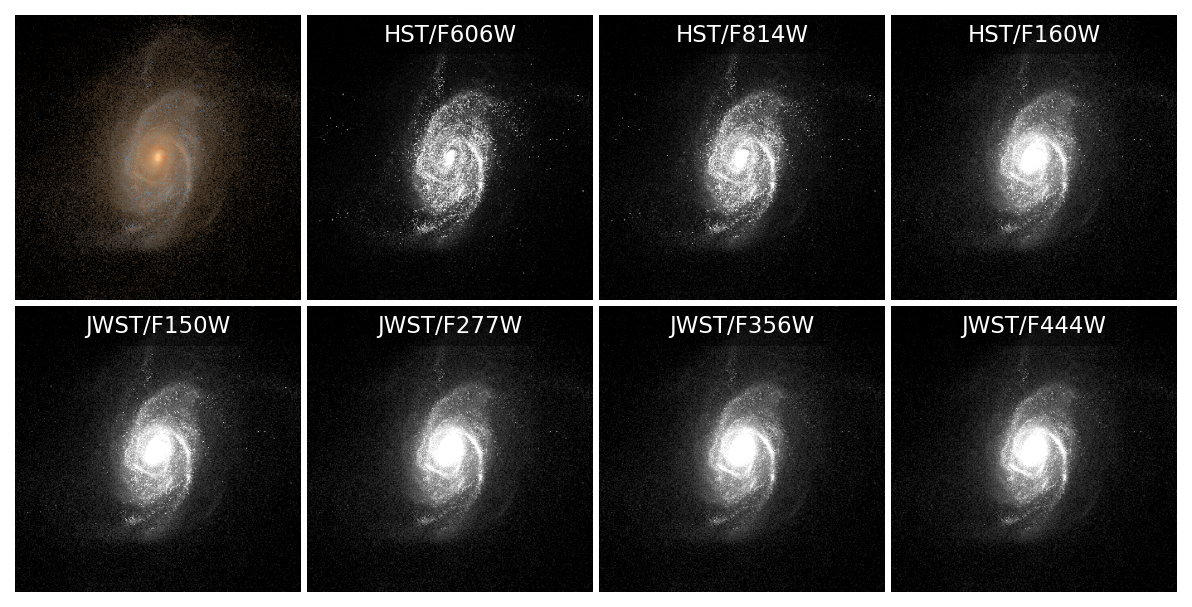

In [2]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm, make_lupton_rgb

# Filter configuration
fils = ['hst_acs_f606w', 'hst_acs_f814w', 'hst_wfc3_ir_f160w', 'jwst_nircam_f150w', 
        'jwst_nircam_f277w', 'jwst_nircam_f356w', 'jwst_nircam_f444w']
filnames = ['HST/F606W', 'HST/F814W', 'HST/F160W', 'JWST/F150W', 
            'JWST/F277W', 'JWST/F356W', 'JWST/F444W']
nbands = len(fils)

# RGB components (using JWST NIRCam filters)
rgb_fils = ['jwst_nircam_f115w', 'jwst_nircam_f150w', 'jwst_nircam_f200w']

nrows, ncols = 2, 4
fig = plt.figure(figsize=(ncols*2.5, nrows*2.5), dpi=150)

# RGB Composite
ax_rgb = fig.add_subplot(nrows, ncols, 1)
factor = 3e+3

# Access data using the standard 'DUST[FILTER]' extension name 
r = cube[f'DUST_{rgb_fils[2]}'].data * factor
g = cube[f'DUST_{rgb_fils[1]}'].data * factor
b = cube[f'DUST_{rgb_fils[0]}'].data * factor

rgb = make_lupton_rgb(r, g, b, stretch=20, Q=15)
ax_rgb.imshow(rgb, origin='lower')
ax_rgb.axis('off') # Cleanly removes all ticks and labels

# Individual Grayscale Bands
for ii in range(nbands):
    ax = fig.add_subplot(nrows, ncols, ii+2)
    
    # Access dust-attenuated imaging data 
    data = cube[f'DUST_{fils[ii]}'].data
    
    # Apply square-root normalization to improve dynamic range visibility
    norm = simple_norm(data, 'sqrt', percent=97.5)
    ax.imshow(data, norm=norm, origin='lower', cmap='gray')
    ax.axis('off')

    # Add filter labels with a small background box for readability
    ax.text(0.5, 0.93, filnames[ii], color='white', fontsize=11,
            ha='center', va='center', transform=ax.transAxes,
            bbox=dict(facecolor='black', alpha=0.4, lw=0))

plt.subplots_adjust(hspace=0.02, wspace=0.02)
plt.show()

Next, we check spectrum integrated within a circular aperture around the galaxy's center along with maps of [OIII] and $H_{\alpha}$ 

/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_11374/2418942518.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()
/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_11374/2418942518.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()


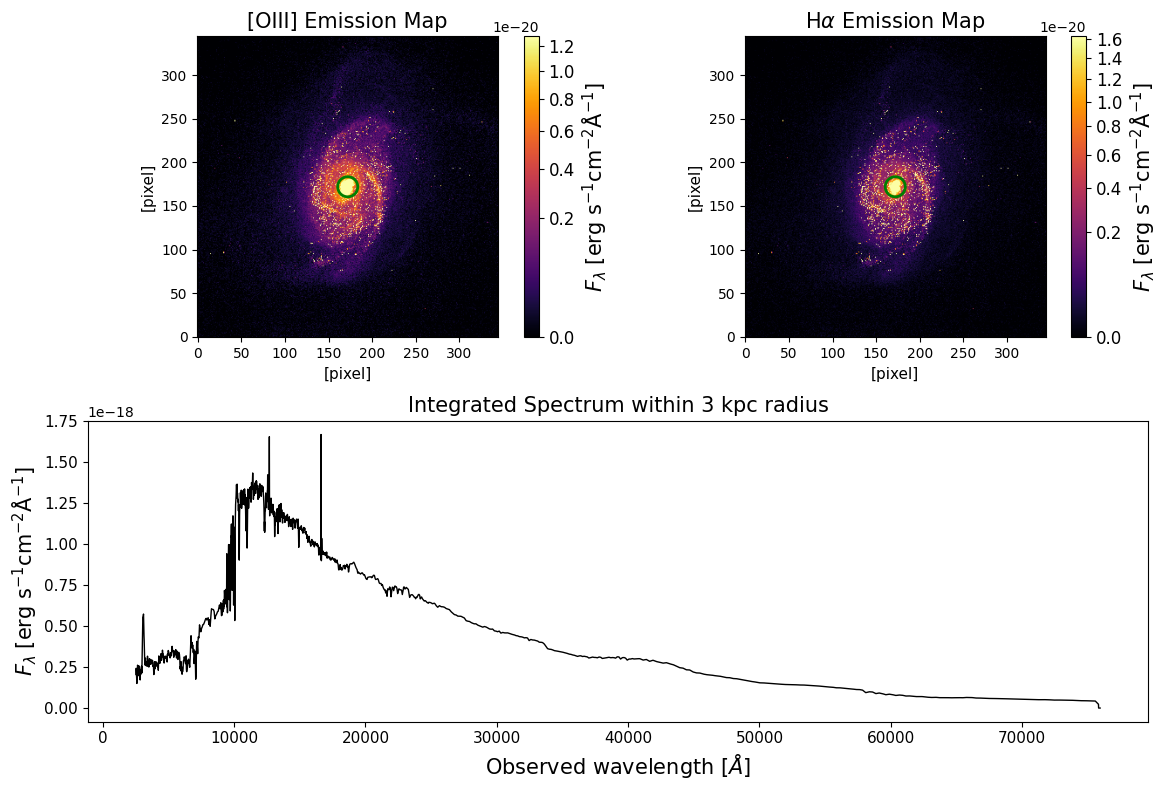

In [5]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches 
import matplotlib.cm as cm
import numpy as np 

sci_data = cube['OBS_SPEC_DUST'].data
wavelength = cube['WAVELENGTH_GRID'].data['WAVELENGTH']

pix_kpc = cube[0].header['pix_kpc'] 
radius_kpc = 3.0
radius_pixels = radius_kpc / pix_kpc

# Select wavelength grids around the OIII and H-alpha lines
oiii_wave_range = [5007*(1.0+z)-100, 5007*(1.0+z)+100]
halpha_wave_range = [6564*(1.0+z)-100, 6564*(1.0+z)+100]
oiii_indices = np.where((wavelength >= oiii_wave_range[0]) & (wavelength <= oiii_wave_range[1]))[0]
halpha_indices = np.where((wavelength >= halpha_wave_range[0]) & (wavelength <= halpha_wave_range[1]))[0]

# Integrate to get the 2D maps
oiii_map = np.sum(sci_data[oiii_indices, :, :], axis=0)
halpha_map = np.sum(sci_data[halpha_indices, :, :], axis=0)

# Get the spatial dimensions
nz, ny, nx = sci_data.shape
center_x, center_y = (nx-1.0)/2.0, (ny-1.0)/2.0

# Create a circular mask
y, x = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
mask = dist_from_center <= radius_pixels

# Create masked data cube
masked_sci_data0 = sci_data * mask

# Integrated spectrum
integrated_spectrum0 = np.sum(masked_sci_data0, axis=(1, 2))

# Create the multipanel plot
plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# OIII map
ax0 = plt.subplot(gs[0, 0])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(oiii_map, 'sqrt', percent=98.5)
im0 = ax0.imshow(oiii_map, norm=norm, origin='lower', cmap=cmap)

ax0.set_title('[OIII] Emission Map', fontsize=15)
ax0.set_xlabel('[pixel]', fontsize=11)
ax0.set_ylabel('[pixel]', fontsize=11)
#plt.colorbar(im0, ax=ax0, label='Integrated Flux')

cbar = plt.colorbar(im0, ax=ax0)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to OIII map
circle0 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax0.add_patch(circle0)
# End of new code

# H-alpha map
ax1 = plt.subplot(gs[0, 1])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(halpha_map, 'sqrt', percent=98.5)
im1 = ax1.imshow(halpha_map, norm=norm, origin='lower', cmap=cmap)

ax1.set_title(r'H$\alpha$ Emission Map', fontsize=15)
ax1.set_xlabel('[pixel]', fontsize=11)
ax1.set_ylabel('[pixel]', fontsize=11)

cbar = plt.colorbar(im1, ax=ax1)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to H-alpha map
circle1 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax1.add_patch(circle1)
# End of new code

# Integrated spectrum
ax2 = plt.subplot(gs[1, :])
ax2.plot(wavelength, integrated_spectrum0, lw=1, color='black')
ax2.set_title('Integrated Spectrum within 3 kpc radius', fontsize=15)
ax2.set_xlabel(r'Observed wavelength [$\AA$]', fontsize=15)
ax2.set_ylabel(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
plt.setp(ax2.get_yticklabels(), fontsize=11)
plt.setp(ax2.get_xticklabels(), fontsize=11)

plt.tight_layout()
#plt.show()
plt.savefig('stamp_ifu1.png', bbox_inches='tight')